In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy.special import jn
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter
#import jcamp as jc

In [3]:


# Load the file. We use allow_pickle=True because it contains a Python dictionary.
# The .item() extracts the dictionary from the 0-D numpy array it gets wrapped in.
data = np.load('processed_data\jasper\jasper_processed_data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 1. Let's check X just to be sure it IS an array
print("Type of X:", type(data['X']))
if hasattr(data['X'], 'shape'):
    print("Shape of X:", data['X'].shape)

# 2. Let's peek inside the dictionary 'A'
print("\nType of A:", type(data['A']))
if isinstance(data['A'], dict):
    print("Keys inside A:", data['A'].keys())

# 3. Let's peek inside the dictionary 'S'
print("\nType of S:", type(data['S']))
if isinstance(data['S'], dict):
    print("Keys inside S:", data['S'].keys())

# 3. (Optional) Look at a small slice of the actual numbers
#print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <class 'numpy.ndarray'>
Shape of X: (198, 10000)

Type of A: <class 'dict'>
Keys inside A: dict_keys(['A_ref', 'A_fclsu', 'A_MBO', 'A_graphL', 'A_MSC', 'A_qmv', 'A_nmf', 'A_EGU'])

Type of S: <class 'dict'>
Keys inside S: dict_keys(['S_ref', 'S_fclsu', 'S_MBO', 'S_graphL', 'S_MSC', 'S_qmv', 'S_nmf', 'S_EGU'])


In [4]:
# Load the file. We use allow_pickle=True because it contains a Python dictionary.
# The .item() extracts the dictionary from the 0-D numpy array it gets wrapped in.
data = np.load('processed_data\jasper\data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (HSI Image):", data['X'].shape)
print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (100, 100, 198)
Shape of A_gt (Abundance Map): (4, 10000)
Shape of S_gt (Endmember Spectra): (198, 4)

First pixel's spectra in X:
 [0.0202 0.0028 0.0236 0.0474 0.0574 0.0636 0.065  0.0676 0.0706 0.073
 0.0772 0.0816 0.0956 0.1084 0.1204 0.1252 0.1318 0.1274 0.124  0.1204
 0.1206 0.1196 0.1194 0.1198 0.1196 0.1162 0.1134 0.1116 0.112  0.1138
 0.1146 0.1182 0.1444 0.201  0.2608 0.3234 0.373  0.41   0.4372 0.4474
 0.4636 0.475  0.4848 0.4906 0.4942 0.5018 0.51   0.5194 0.5296 0.5342
 0.5442 0.5528 0.5598 0.5678 0.5734 0.5754 0.5788 0.5774 0.5814 0.5764
 0.5846 0.5872 0.5866 0.5938 0.6032 0.6102 0.6184 0.6274 0.6322 0.6394
 0.6478 0.6546 0.6684 0.6664 0.6668 0.666  0.6566 0.647  0.6476 0.6342
 0.6242 0.6162 0.6192 0.6206 0.6238 0.6296 0.6354 0.6482 0.6594 0.6678
 0.6716 0.6746 0.6786 0.6872 0.693  0.6928 0.693  0.691  0.701  0.7104
 0.7042 0.6898 0.6768 0.6574 0.3046 0.289  0.2708 0.285  0.2782 0.2854
 0.287  0.

(10, 200, 30)
(30, 2)
(2, 2000)
[[0.75775404 0.95114148 0.29408707 ... 0.87927888 0.23043933 0.86231223]
 [0.24224596 0.04885852 0.70591293 ... 0.12072112 0.76956067 0.13768777]]


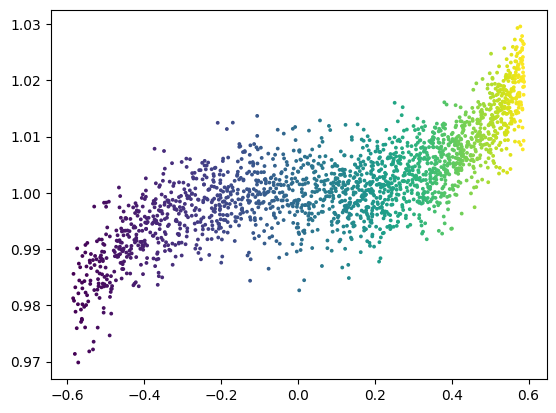

In [ ]:
num_points = 2000
h=10
error_std = 0.005
power = 3
start_end = 1.7
fl = 10
dims = 30


labels =  np.random.uniform(low=1/np.exp(1/start_end), high=np.exp(1/start_end), size=num_points)
s_l = 1/np.exp(1/start_end)
e_l = np.exp(1/start_end)
true = [s_l,e_l]

colors =( labels - np.min(labels))/(np.max(labels) - np.min(labels)+0.01)+0.005

noise = np.random.normal(loc=0.0, scale=error_std, size=labels.shape)
X_data = np.log(labels) 
x_true = np.log(true)
Y_data_pure = 1/fl*np.power(X_data,power)+1
y_true = 1/fl*np.power(x_true,power)+1
Y_data = Y_data_pure + noise
plt.scatter(X_data, Y_data, s= 3, c = colors)

embedding_mat = np.abs(np.random.normal(loc = 12, scale = 0.5, size =(dims,2) ))+0.00001

raw_data = embedding_mat @ [X_data, Y_data]



end_members = embedding_mat@[x_true,y_true]


label_mat = np.abs([colors, 1-colors])

data_min = np.min(raw_data)
data_max = np.max(raw_data)

# Scale both the raw data and the ground truth spectra identically
raw_data = (raw_data - data_min) / (data_max - data_min)
end_members = (end_members - data_min) / (data_max - data_min)

data_mat = raw_data.T.reshape(h,(int) (num_points/h), dims)

print(data_mat.shape)
print(end_members.shape)
print(label_mat.shape)
print(label_mat)


In [59]:
A_gt = label_mat
S_gt = end_members
custom_dataset = {
    'X': data_mat,
    'A_gt': A_gt,
    'S_gt': S_gt
}
np.save('my_custom_dataset.npy', custom_dataset)

In [60]:
data = np.load('my_custom_dataset.npy', allow_pickle=True).item()

# 1. See what keys are inside
# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (HSI Image):", data['X'].shape)
print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (10, 200, 30)
Shape of A_gt (Abundance Map): (2, 2000)
Shape of S_gt (Endmember Spectra): (30, 2)

First pixel's spectra in X:
 [0.81398425 0.7598123  0.73758418 0.7607683  0.85012907 0.76795601
 0.74572635 0.74654225 0.77583324 0.78226273 0.76083552 0.76814615
 0.76405294 0.72709973 0.81239116 0.7617668  0.74811121 0.79574907
 0.71230459 0.76753097 0.73678258 0.80008983 0.7651702  0.77070471
 0.73729039 0.78892379 0.7745506  0.83179654 0.815688   0.76592207]
